<a href="https://colab.research.google.com/github/TejasKayarkar03/Pattern-Recognition-Lab/blob/main/PR_CM23045_Pr5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ucimlrepo openpyxl scipy -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score


In [ ]:
from ucimlrepo import fetch_ucirepo

# Fetch Online Retail dataset
online_retail = fetch_ucirepo(id=352)

# Features and target
df = online_retail.data.original

print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
import pandas as pd
import numpy as np

# Remove missing customer IDs
df = df.dropna(subset=['CustomerID'])

# Remove returns/cancellations
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Create Total Amount
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

print(df.shape)

(397884, 9)


In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

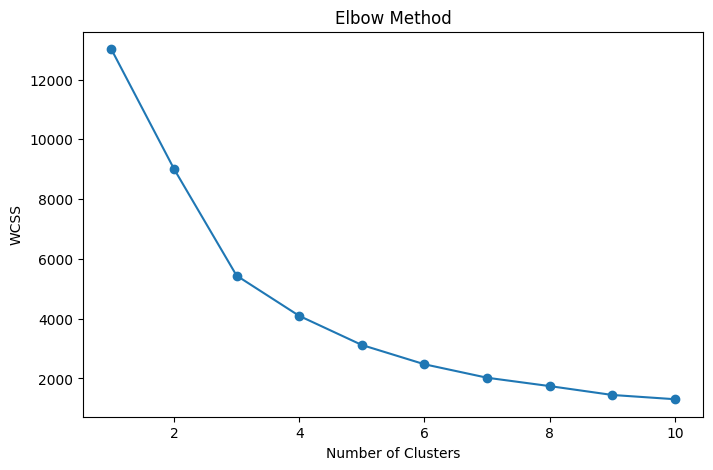

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['KMeans_Cluster'] = kmeans.fit_predict(rfm_scaled)

print(rfm['KMeans_Cluster'].value_counts())

KMeans_Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64


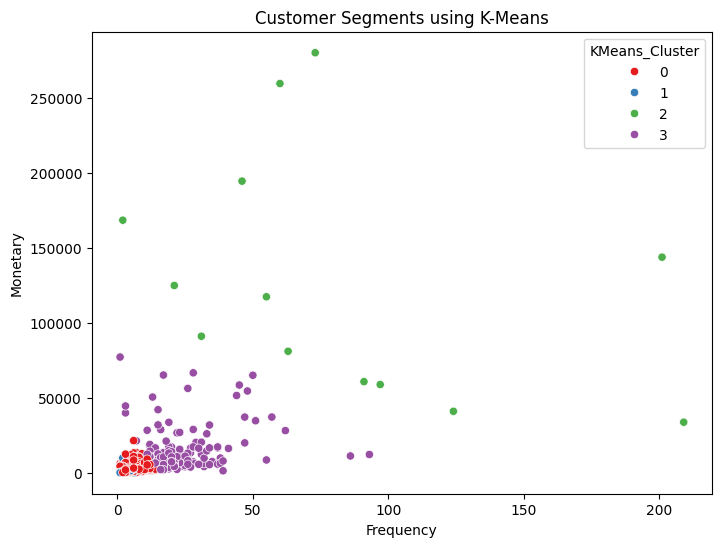

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='KMeans_Cluster',
    palette='Set1'
)

plt.title("Customer Segments using K-Means")
plt.show()

In [ ]:
cluster_summary = rfm.groupby('KMeans_Cluster').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
})

print(cluster_summary)

                   Recency  Frequency       Monetary
KMeans_Cluster                                      
0                43.702685   3.682711    1359.049284
1               248.075914   1.552015     480.617480
2                 7.384615  82.538462  127338.313846
3                15.500000  22.333333   12709.090490


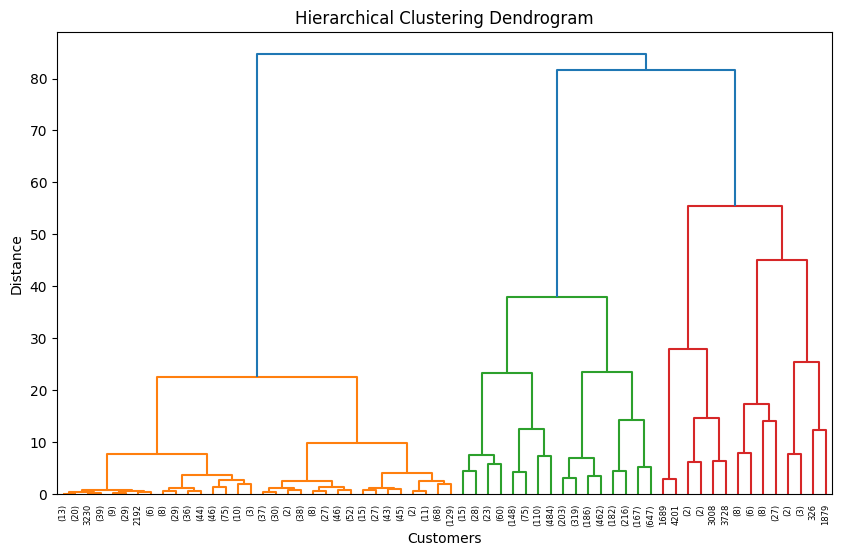

In [28]:
from scipy.cluster.hierarchy import dendrogram, linkage
linked = linkage(rfm_scaled, method='ward')
plt.figure(figsize=(10,6))
dendrogram(
    linked,
    truncate_mode='level',
    p=5
)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()